![New York City schoolbus](../images/schoolbus.jpg)

Photo by [Jannis Lucas](https://unsplash.com/@jannis_lucas) on [Unsplash](https://unsplash.com).
<br>

Every year, American high school students take SATs, which are standardized tests intended to measure literacy, numeracy, and writing skills. There are three sections - reading, math, and writing, each with a **maximum score of 800 points**. These tests are extremely important for students and colleges, as they play a pivotal role in the admissions process.

Analyzing the performance of schools is important for a variety of stakeholders, including policy and education professionals, researchers, government, and even parents considering which school their children should attend. 

We have been provided with a dataset called `schools.csv`, which is previewed below.

We have been tasked with answering three key questions about New York City (NYC) public school SAT performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read in the data
schools = pd.read_csv("../data/schools.csv")

# Preview the data
print(schools.shape)
schools.head()

(375, 7)


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


## Schools in each boroughs

I don't know much about NYC, so folks like me need to ask things like ***how many boroughs are there?*** before even looking into how many schools are in each one.

In [2]:
schools.groupby(by='borough')['school_name'].agg('count').reset_index()  # five boroughs

,borough,school_name
0,Bronx,98
1,Brooklyn,109
2,Manhattan,89
3,Queens,69
4,Staten Island,10


In [3]:
schools.describe()

,average_math,average_reading,average_writing,percent_tested
count,375.000000,375.000000,375.000000,355.000000
mean,432.944000,424.504000,418.458667,64.976338
std,71.952373,61.881069,64.548599,18.747634
min,317.000000,302.000000,284.000000,18.500000
25%,386.000000,386.000000,382.000000,50.950000
50%,415.000000,413.000000,403.000000,64.800000
75%,458.500000,445.000000,437.500000,79.600000
max,754.000000,697.000000,693.000000,100.000000


## Do SAT topics tend to cluster in any significant way?

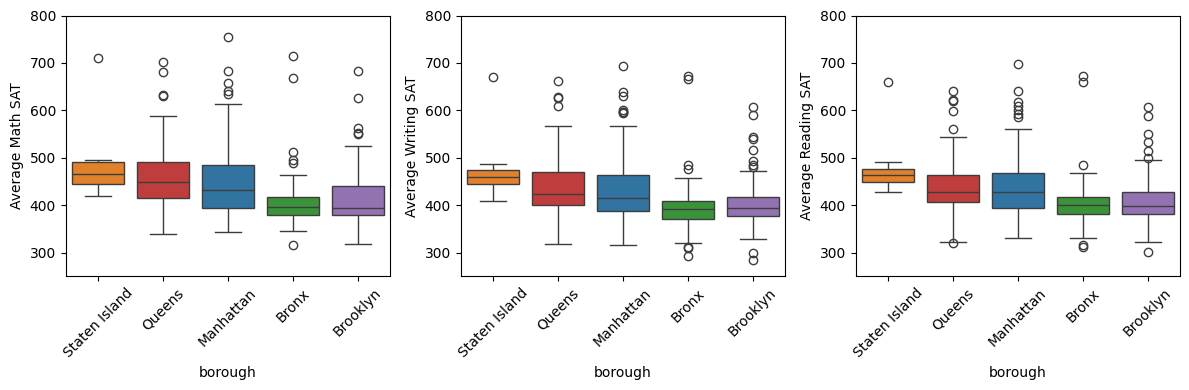

In [4]:
fig1, ax1 = plt.subplots(1, 3, figsize=(12, 4))
# https://github.com/stipub/stixfonts/blob/master/docs/STIXTwoMath-Regular.pdf
# ax1[0].plot(schools["average_math"], schools["average_reading"], marker= '$\u00BA$', linestyle="None")
# https://matplotlib.org/api/markers_api.html
# ax1[1].plot(schools["average_math"], schools["average_writing"], marker='+', linestyle="None")
# ax1[2].plot(schools["average_writing"], schools["average_reading"], marker='x', linestyle="None")

# order from high to low borough L-to-R
hue_ord = schools.groupby("borough")["average_math"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=schools, x="borough", y="average_math", hue="borough", order=hue_ord, ax=ax1[0])
sns.boxplot(data=schools, x="borough", y="average_writing", hue="borough", order=hue_ord, ax=ax1[1])
sns.boxplot(data=schools, x="borough", y="average_reading", hue="borough", order=hue_ord, ax=ax1[2])

ax1[0].set_ylabel("Average Math SAT")
ax1[1].set_ylabel("Average Writing SAT")
ax1[2].set_ylabel("Average Reading SAT")
# make x-ticks readable, and y-axis range the same for easier comparison
for i in range(3):
    ax1[i].tick_params(axis='x', labelrotation=45)
    ax1[i].set_ylim(250, 800)

plt.tight_layout()
plt.show()

In [5]:
# Which NYC schools have the best math results? 
df_schools = schools.loc[:, ["school_name", "average_math"]]
best_lower_bound = 0.8 * 800
best_math_schools = df_schools.loc[df_schools["average_math"] >= best_lower_bound, :]
best_math_schools = best_math_schools.sort_values(["average_math"], ascending=False)
best_math_schools

,school_name,average_math
88,Stuyvesant High School,754
170,Bronx High School of Science,714
93,Staten Island Technical High School,711
365,Queens High School for the Sciences at York Co...,701
68,"High School for Mathematics, Science, and Engi...",683
280,Brooklyn Technical High School,682
333,Townsend Harris High School,680
174,High School of American Studies at Lehman College,669
0,"New Explorations into Science, Technology and ...",657
45,Eleanor Roosevelt High School,641


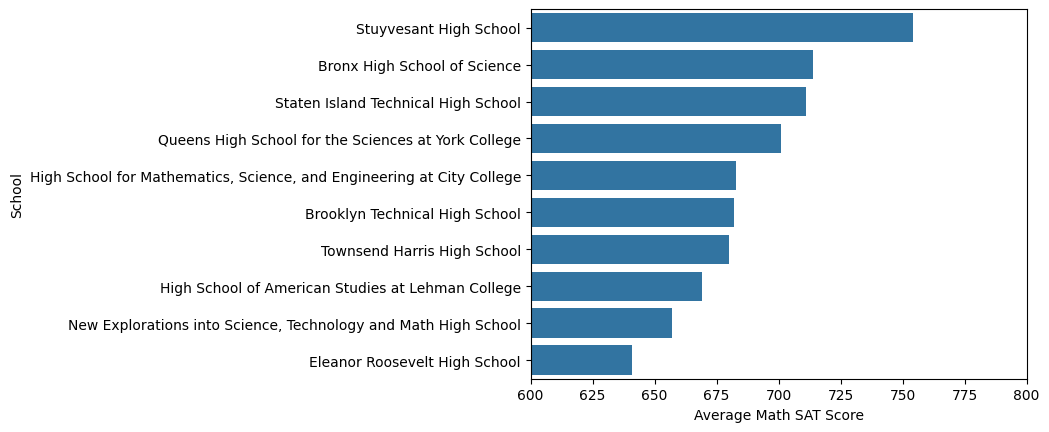

In [6]:
# visualize
g = sns.barplot(x='average_math', y='school_name', data=best_math_schools)
g.set_xlabel("Average Math SAT Score")
g.set_ylabel("School")
# make the differences easier to see
plt.xlim(600, 800)
plt.show()

In [7]:
# What are the top 10 performing schools based on the combined SAT scores?
df_schools_sat = schools.loc[:, ['school_name', 'average_math', 'average_reading', 'average_writing']]
df_schools_sat['total_SAT'] = df_schools_sat['average_math'] + df_schools_sat['average_reading'] + df_schools_sat['average_writing']
df_schools_sat.sort_values(['total_SAT'], ascending=False, inplace=True)
top_10_schools = df_schools_sat.iloc[0:10]
top_10_schools = top_10_schools.loc[:, ['school_name', 'total_SAT']]
top_10_schools

,school_name,total_SAT
88,Stuyvesant High School,2144
170,Bronx High School of Science,2041
93,Staten Island Technical High School,2041
174,High School of American Studies at Lehman College,2013
333,Townsend Harris High School,1981
365,Queens High School for the Sciences at York Co...,1947
5,Bard High School Early College,1914
280,Brooklyn Technical High School,1896
45,Eleanor Roosevelt High School,1889
68,"High School for Mathematics, Science, and Engi...",1889


In [8]:
# Which single borough has the largest standard deviation in the combined SAT score?
import numpy as np

df_borough_sat = schools.loc[:, ['borough', 'average_math', 'average_reading', 'average_writing']]
df_borough_sat['total_SAT'] = df_borough_sat['average_math'] + df_borough_sat['average_reading'] + df_borough_sat['average_writing']
# df_borough_sat_grouped = df_borough_sat.pivot_table(values="total_SAT", index="borough", aggfunc=[np.mean, np.std])  # gives FutureWarning...
df_borough_sat_grouped = df_borough_sat.pivot_table(values="total_SAT", index="borough", aggfunc=["count", "mean", "std"])
# df_borough_sat_grouped.sort_values(['total_SAT'], ascending=False, inplace=True)
df_borough_stats = pd.DataFrame(df_borough_sat_grouped.to_records())  # https://datascientyst.com/convert-pivot-table-to-regular-data-frame-in-pandas/
df_borough_stats.rename(columns = {"('count', 'total_SAT')":"num_schools",
                                   "('mean', 'total_SAT')": "average_SAT",
                                   "('std', 'total_SAT')": "std_SAT"},
                       inplace = True)
df_borough_stats.sort_values(["std_SAT"], ascending=False, inplace=True)
# rounding in pandas is goofy: https://stackoverflow.com/questions/38255796/pandas-round-is-not-working-for-dataframe
df_borough_stats["num_schools"] = df_borough_stats["num_schools"].astype(float).round(2)
df_borough_stats["average_SAT"] = df_borough_stats["average_SAT"].astype(float).round(2)
df_borough_stats["std_SAT"] = df_borough_stats["std_SAT"].astype(float).round(2)
largest_std_dev = df_borough_stats.iloc[0:1, :]

largest_std_dev

,borough,num_schools,average_SAT,std_SAT
2,Manhattan,89.0,1340.13,230.29
